# 🐱 Detecção e classificação de raças de gatos

**Trabalho final — Aprendizado Profundo · PPGCA / UNIVALI**
Thiago Haas Rausch · Bruna Henning Pereira · Prof. Felipe Viel

Pipeline completo: **YOLOv8n** detecta o gato, **ResNet50** classifica a raça
entre 22 classes, **Grad-CAM** mostra o que pesou na decisão e a regra **SRD**
rejeita previsões de baixa confiança.

## Mapa do checklist de entrega

Cada item do checklist (Seção 14 do enunciado) tem a sua seção aqui:

| # | Item do checklist | Seção |
|---|---|---|
| 1 | Problema claramente definido | [1](#1) |
| 2 | Motivação apresentada | [1](#1) |
| 3 | Dataset descrito e fonte registrada | [3](#3) |
| 4 | Análise exploratória realizada | [4](#4) |
| 5 | Problemas dos dados identificados | [5](#5) |
| 6 | Pré-processamento documentado | [6](#6) |
| 7 | Divisão treino/validação/teste definida | [7](#7) |
| 8 | Arquitetura justificada | [8](#8) |
| 9 | Baseline implementado | [9](#9) e [10](#10) |
| 10 | Pelo menos duas variações experimentais | [10](#10) |
| 11 | Histórico de treinamento apresentado | [11](#11) |
| 12 | Métricas apropriadas utilizadas | [12](#12) |
| 13 | Resultados comparados em tabela e/ou gráfico | [13](#13) |
| 14 | Limitações discutidas | [16](#16) e [17](#17) |
| 15 | Código organizado | [2](#2) e [17](#17) |
| 16 | Relatório e apresentação | [17](#17) |

## Como executar

Selecione o kernel `.venv/bin/python` e rode as células **em ordem**. Em GPU o
Run All completo leva cerca de **15 minutos**; sem GPU, horas — a Seção 2 avisa
qual é o caso antes de qualquer treino.

Os dados, os pesos da ResNet50 e o `yolov8n.pt` são baixados na primeira
execução. Todas as figuras da apresentação são gravadas em
`artifacts/figuras/`.

Os módulos ao lado do notebook guardam o código pesado: `cat_datasets.py`
(download e limpeza), `cat_experimentos.py` (treino, experimentos e análise
SRD), `cat_graficos.py` (figuras) e `cat_landmarks.py` (pontos faciais).

<a id="1"></a>
## 1. Problema, motivação e escopo
**Checklist 1 e 2 · Rubrica: definição e contextualização do problema (10%)**

**Problema.** Dada uma foto, detectar o gato e atribuir a raça entre 22 classes.
É o **Problema 1 do enunciado** — classificação de imagens. A variável-alvo é a
raça: categórica, 22 níveis.

**Por que uma rede convolucional.** A raça se distingue por textura de pelo,
formato de orelha e focinho: relações locais e espaciais, que é exatamente o
que a convolução explora. Um MLP sobre pixels ignoraria essa estrutura.

**Motivação.** Em adoção e resgate, a raça orienta cuidados, alimentação e
predisposição a doenças. Uma ferramenta de consulta rápida, rodando no celular
sem enviar a foto a servidor nenhum, resolve isso de forma prática. Para a
disciplina, o problema é um caso completo: classes visualmente próximas,
desbalanceadas, e uma categoria do mundo real que **não existe no dataset** —
o gato sem raça definida.

**Escopo declarado.** A saída é uma sugestão entre as classes aprendidas. Não é
prova de genealogia, e confiança alta não é garantia de acerto — a Seção 16
mede exatamente isso.

<a id="2"></a>
## 2. Ambiente, dependências e reprodutibilidade
**Checklist 15 · Rubrica: organização e reprodutibilidade do código (5%)**

Semente única fixada em `random`, `numpy` e `torch`; revisão do dataset externo
fixada por commit; dependências declaradas em `requirements.txt`.

`preparar_gpu()` liga precisão mista, `channels_last`, `cudnn.benchmark`, TF32 e
os processos do `DataLoader` — e, se cair em CPU, diz o motivo. **Confira a
saída da próxima célula antes de seguir**: em CPU os treinos levam horas.

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
import json
import shutil
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from torchvision.datasets.utils import download_and_extract_archive
from torchvision.transforms import functional as TF

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

Usando device: cuda


In [3]:
import importlib

import cat_experimentos as ce
import cat_graficos as cg
importlib.reload(ce)
importlib.reload(cg)

PROJECT_DIR = Path.cwd().resolve()
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
EXP_DIR = ARTIFACTS_DIR / "experimentos"
FIG_DIR = cg.definir_saida(ARTIFACTS_DIR / "figuras")

# Diagnóstico da GPU e configuração de desempenho.
acel = ce.preparar_gpu()

torch 2.14.0+cu130  ·  CUDA da build: 13.0
GPU: NVIDIA GeForce RTX 3080  ·  10.4 GB  ·  capability 8.6
Acelerador(device=cuda, precisão=bfloat16 (AMP), workers=8)


### 2.1. Hiperparâmetros

Este é o **único lugar** a editar para mudar o treino. O resto do notebook e os
experimentos leem daqui.

In [4]:
CONFIG = {
    # ---------- Dados / split ----------
    "DATASET_MODE": "both",  # "oxford", "cat_breeds" ou "both"
    "IMG_SIZE": 224,          # resolução de entrada da rede
    "BATCH_SIZE": 32,
    # Em notebooks locais, subprocessos podem falhar ao importar classes
    # definidas nas células (especialmente com forkserver no Python 3.14+).
    "NUM_WORKERS": 0,
    "PIN_MEMORY": device.type == "cuda",
    "VAL_FRAC": 0.15,
    "TEST_FRAC": 0.15,
    "SEED": 42,               # semente única -> resultados reprodutíveis

    # ---------- Data augmentation (treino) ----------
    # Valores conservadores: augmentation ajuda a generalizar, mas em excesso
    # distorce demais a imagem e pode atrapalhar o aprendizado.
    "AUG_HFLIP_PROB": 0.5,          # espelhamento horizontal
    "AUG_ROTATION_DEG": 15,         # rotação aleatória em graus (+/-)
    "AUG_BRIGHTNESS": 0.2,          # variação de luminosidade (brilho)
    "AUG_CONTRAST": 0.2,            # variação de contraste
    "AUG_SATURATION": 0.2,          # variação de saturação
    "AUG_HUE": 0.03,                # variação de matiz (leve)
    "AUG_BLUR_PROB": 0.2,           # chance de aplicar blur gaussiano
    "AUG_BLUR_KERNEL": 3,           # tamanho do kernel do blur (ímpar, menor = mais sutil)
    "AUG_BLUR_SIGMA": (0.1, 1.2),   # intensidade (sigma) do blur
    "AUG_ERASING_PROB": 0.25,       # chance de aplicar "cutout" (caixinhas aleatórias)
    "AUG_ERASING_SCALE": (0.02, 0.10),  # área da caixinha (fração da imagem)
    "AUG_ERASING_RATIO": (0.3, 3.3),    # proporção largura/altura da caixinha

    # ---------- Pontos faciais: modelo separado treinado no CAT Dataset ----------
    "LANDMARKS_MODE": "off",  # "train": treina/exporta; "load": carrega; "off": desativa
    "LANDMARKS_EPOCHS": 30,
    "LANDMARKS_BATCH": 16,
    "LANDMARKS_IMG_SIZE": 640,
    "LANDMARKS_CONF": 0.25,
    "LANDMARKS_SHOW_RESULTS": True,  # exibir diagnóstico após treino/carga
    "LANDMARKS_EXAMPLES": 3,        # exemplos anotados vs. previstos do teste CAT

    # ---------- Modelo ----------
    "DROPOUT": 0.5,                 # dropout antes da camada final (aumentado para reduzir overfitting)

    # ---------- Fase 1: treino da "cabeça" (backbone congelado) ----------
    "HEAD_LR": 1e-3,
    "HEAD_WEIGHT_DECAY": 3e-4,      # regularização L2 (aumentada para reduzir overfitting)
    "HEAD_EPOCHS": 30,              # early stopping deve parar antes disso
    "HEAD_PATIENCE": 5,             # épocas sem melhora até parar

    # ---------- Fase 2: fine-tuning (descongela parte do backbone) ----------
    "FT_UNFREEZE_LAYERS": ["layer3", "layer4", "fc"],  # blocos da ResNet a descongelar
    "FT_LR": 1e-5,
    "FT_WEIGHT_DECAY": 3e-4,        # regularização L2 (aumentada para reduzir overfitting)
    "FT_EPOCHS": 20,
    "FT_PATIENCE": 5,

    # ---------- Regularização geral / scheduler ----------
    # Smoothing leve: ajuda a generalizar (reduz overfitting) sem deixar o
    # loss ilegível (com 0.1 o "piso" matemático do loss fica perto de 0.5;
    # com 0.05 esse efeito é bem mais discreto).
    "LABEL_SMOOTHING": 0.05,
    "LR_SCHEDULER_FACTOR": 0.5,     # reduz LR pela metade quando val_loss estagna
    "LR_SCHEDULER_PATIENCE": 2,     # épocas de estagnação até reduzir o LR
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CONFIG["SEED"])
print("CONFIG carregado. Semente fixada em", CONFIG["SEED"])

CONFIG carregado. Semente fixada em 42


In [5]:
# Ajustes que dependem do hardware, aplicados depois do CONFIG para ficarem à vista.
# Com precisão mista cabe o dobro por batch e a GPU passa menos tempo ociosa.
if acel.na_gpu and CONFIG["BATCH_SIZE"] < 64:
    CONFIG["BATCH_SIZE"] = 64
    print("BATCH_SIZE ajustado para 64 — GPU com precisão mista.")

# Chaves que só os experimentos usam ganham o valor padrão do módulo.
CONFIG = ce.completar_config(CONFIG)

print({chave: CONFIG[chave] for chave in
       ("IMG_SIZE", "BATCH_SIZE", "SEED", "AUG_ENABLED", "HEAD_EPOCHS", "FT_EPOCHS")})

BATCH_SIZE ajustado para 64 — GPU com precisão mista.
{'IMG_SIZE': 224, 'BATCH_SIZE': 64, 'SEED': 42, 'AUG_ENABLED': True, 'HEAD_EPOCHS': 30, 'FT_EPOCHS': 20}


<a id="3"></a>
## 3. Dataset: fontes, licenças e download
**Checklist 3 · Rubrica: análise e preparação dos dados (15%)**

| Fonte | Raças | Licença |
|---|---|---|
| [Oxford-IIIT Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/) | 12 | uso acadêmico |
| [Cat Breeds Dataset](https://github.com/AtharvaTaras/Cat-Breeds-Dataset), de Atharva Taras | 20 | [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) |

A união padronizada tem **22 classes**. O download do segundo dataset está
fixado em um commit (`DATASET_REVISION` em `cat_datasets.py`), para a execução
ser reprodutível mesmo se o repositório de origem mudar.

Alterações feitas na integração: padronização dos rótulos (`maine_coon_cat` →
`Maine_Coon`), exclusão de imagens ilegíveis, de duplicatas exatas e de
conflitos de rótulo. Escolha a fonte em `CONFIG["DATASET_MODE"]`.

In [6]:
PROJECT_DIR = Path.cwd().resolve()
DATASET_MODE = CONFIG["DATASET_MODE"]
if DATASET_MODE not in ("oxford", "cat_breeds", "both"):
    raise ValueError('DATASET_MODE deve ser "oxford", "cat_breeds" ou "both".')

DATA_DIR = PROJECT_DIR / "data" / "oxford_pets"
if DATASET_MODE in ("oxford", "both"):
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    dataset_files = {
        "images": "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz",
        "annotations": "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz",
    }

    for folder_name, url in dataset_files.items():
        if not (DATA_DIR / folder_name).is_dir():
            download_and_extract_archive(url, download_root=str(DATA_DIR))
        else:
            print(f"{folder_name}/ já existe; download ignorado.")

    print(f"Dataset disponível em: {DATA_DIR}")

print("Seleção de datasets:", DATASET_MODE)

images/ já existe; download ignorado.
annotations/ já existe; download ignorado.
Dataset disponível em: /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/data/oxford_pets
Seleção de datasets: both


In [7]:
from cat_datasets import (
    DATASET_REVISION, download_cat_breeds, load_cat_breeds, clean_images,
)

# Reconstrói a lista a cada execução, sem reutilizar dados do modo anterior.
dataset_frames = []
if DATASET_MODE in ("oxford", "both"):
    IMAGES_DIR = os.path.join(DATA_DIR, "images")
    ANNOT_DIR = os.path.join(DATA_DIR, "annotations")

    # O arquivo list.txt mapeia: nome_arquivo classe_id espécie(1=gato,2=cachorro) breed_id
    list_path = os.path.join(ANNOT_DIR, "list.txt")
    rows = []
    with open(list_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.strip().split()
            if len(parts) != 4:
                continue
            filename, class_id, species, breed_id = parts
            rows.append((filename, int(class_id), int(species), int(breed_id)))

    df = pd.DataFrame(rows, columns=["filename", "class_id", "species", "breed_id"])

    # species == 1 -> gato. Filtramos só os gatos.
    cats_df = df[df["species"] == 1].copy()

    # Nome da raça = prefixo do nome do arquivo antes do número (ex: "Abyssinian_100" -> "Abyssinian")
    cats_df["breed_name"] = cats_df["filename"].apply(lambda x: "_".join(x.split("_")[:-1]))
    cats_df["filepath"] = cats_df["filename"].apply(lambda x: os.path.join(IMAGES_DIR, x + ".jpg"))
    cats_df = cats_df[cats_df["filepath"].apply(os.path.exists)].reset_index(drop=True)

    cats_df["source"] = "oxford_iiit_pet"
    cats_df["original_label"] = cats_df["breed_name"]
    dataset_frames.append(cats_df)

if DATASET_MODE in ("cat_breeds", "both"):
    extra_images_dir = download_cat_breeds(PROJECT_DIR / "data")
    dataset_frames.append(load_cat_breeds(extra_images_dir))

cats_df = pd.concat(dataset_frames, ignore_index=True)
cats_df, rejected_images = clean_images(cats_df)
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
rejected_images.to_csv(ARTIFACTS_DIR / "dataset_rejections.csv", index=False)
cats_df.to_csv(ARTIFACTS_DIR / "dataset_manifest.csv", index=False)
print(f"Após limpeza: {len(cats_df)} imagens; {cats_df['breed_name'].nunique()} raças.")
print("Exclusões:", rejected_images["reason"].value_counts().to_dict())
print(pd.crosstab(cats_df["breed_name"], cats_df["source"]))

Após limpeza: 7195 imagens; 22 raças.
Exclusões: {'duplicate_image': 11}
source              atharva_taras  oxford_iiit_pet
breed_name                                        
Abyssinian                    234              198
American_Shorthair            193                0
Bengal                        233              200
Birman                        216              200
Bombay                          0              184
British_Shorthair             208              200
Cornish_Rex                   229                0
Devon_Rex                     210                0
Egyptian_Mau                    0              190
Himalayan                     219                0
Maine_Coon                    368              200
Manx                          231                0
Norwegian_Forest              210                0
Oriental_Shorthair            240                0
Persian                       279              200
Ragdoll                       245              200
Russian_B

<a id="4"></a>
## 4. Análise exploratória
**Checklist 4**

Antes de treinar, caracterizamos o conjunto: quantas imagens por raça, de que
fonte vêm e quanto as classes estão desbalanceadas. O gráfico abaixo é o mesmo
que vai para a apresentação.

figura salva em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/dist_classes.png


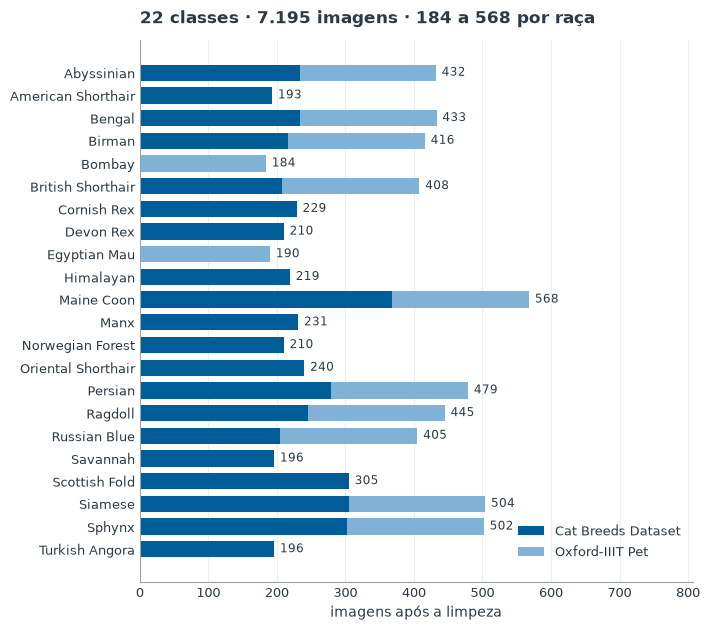

7195 imagens · 22 raças · 2 fontes
Menor classe: Bombay (184) · maior: Maine_Coon (568) · razão 3.1×

Imagens por fonte:
source
atharva_taras      4824
oxford_iiit_pet    2371


In [8]:
# Distribuição por raça e por fonte — figura da apresentação.
cg.distribuicao_classes(cats_df)
plt.show()

por_raca = cats_df["breed_name"].value_counts()
print(f"{len(cats_df)} imagens · {cats_df['breed_name'].nunique()} raças · "
      f"{cats_df['source'].nunique()} fontes")
print(f"Menor classe: {por_raca.idxmin()} ({por_raca.min()}) · "
      f"maior: {por_raca.idxmax()} ({por_raca.max()}) · "
      f"razão {por_raca.max() / por_raca.min():.1f}×")
print("\nImagens por fonte:")
print(cats_df["source"].value_counts().to_string())

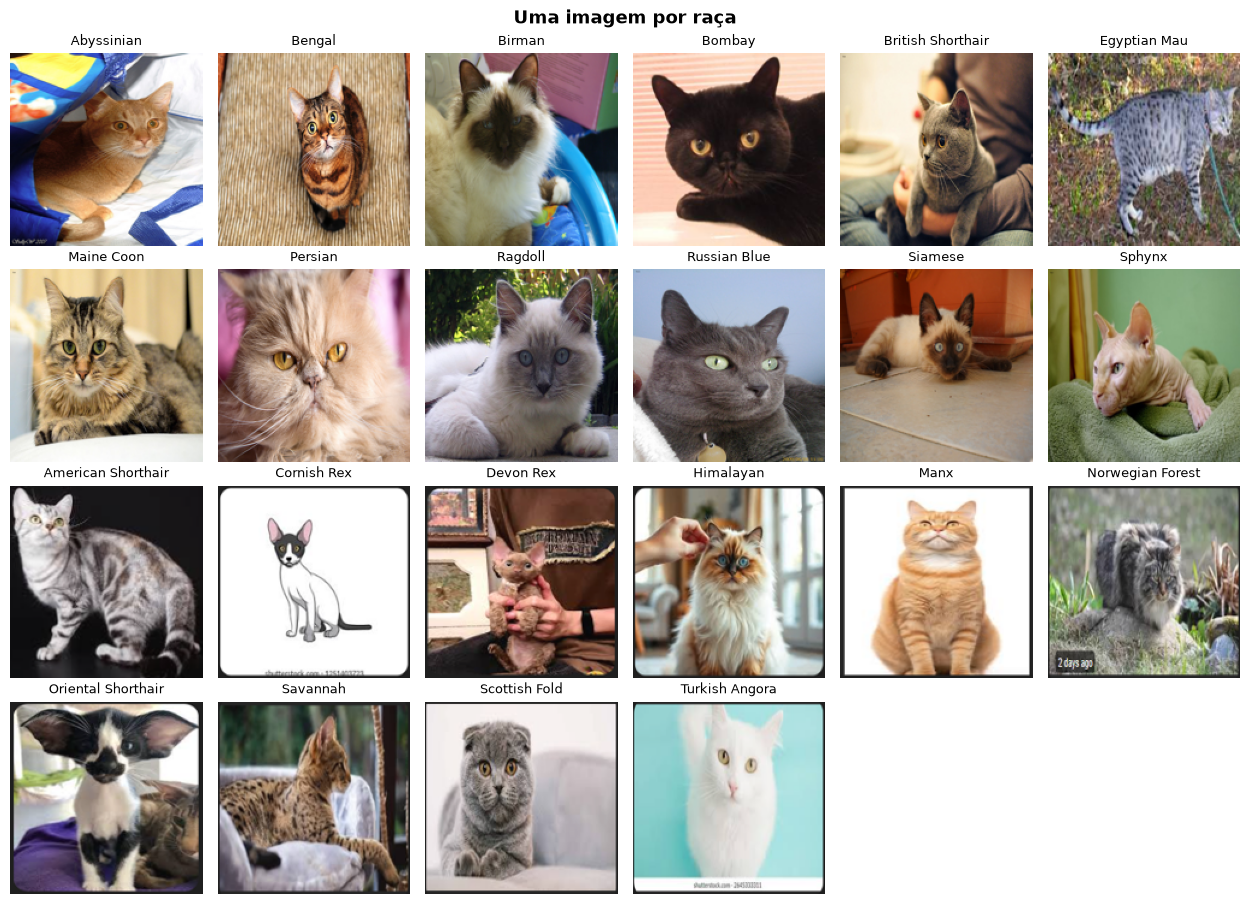

In [9]:
# Uma amostra de cada raça, para ver com o que o modelo vai lidar.
amostra = cats_df.groupby("breed_name", group_keys=False).head(1).reset_index(drop=True)
colunas = 6
linhas = -(-len(amostra) // colunas)
fig, axes = plt.subplots(linhas, colunas, figsize=(2.1 * colunas, 2.3 * linhas))
for ax, (_, row) in zip(axes.ravel(), amostra.iterrows()):
    ax.imshow(Image.open(row["filepath"]).convert("RGB").resize((160, 160)))
    ax.set_title(row["breed_name"].replace("_", " "), fontsize=9)
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("Uma imagem por raça", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

<a id="5"></a>
## 5. Problemas identificados nos dados
**Checklist 5**

| Problema | Como tratamos |
|---|---|
| Imagens ilegíveis | removidas antes do split, registradas em `dataset_rejections.csv` |
| Duplicatas RGB exatas | mantemos uma cópia e removemos as demais |
| Conflito de rótulo entre cópias idênticas | **todas** as cópias são excluídas |
| Classes desbalanceadas | métrica principal passa a ser F1-macro (Seção 12) |
| Ausência de gatos SRD | limitação estrutural, medida na Seção 16 |
| Vazamento entre conjuntos | `assert` por SHA-256 no split (Seção 7) |

Fotos semelhantes, recortadas ou recomprimidas **não** são detectadas por essa
limpeza — é uma limitação conhecida, declarada na Seção 17.

In [10]:
print("Exclusões por motivo:")
print(rejected_images["reason"].value_counts().to_string())
print(f"\nTotal removido: {len(rejected_images)} de "
      f"{len(cats_df) + len(rejected_images)} imagens candidatas")
display(rejected_images.head(8))

Exclusões por motivo:
reason
duplicate_image    11

Total removido: 11 de 7206 imagens candidatas


,filename,class_id,species,breed_id,breed_name,filepath,source,original_label,image_sha256,reason,detail
0,160.png,NaN,NaN,NaN,Maine_Coon,/home/haas/Documents/GitHub/cnn-gatos-deteccao...,atharva_taras,maine_coon_cat,653b64a5e7a1969df2815273c90824bc5ccf23b77b3711...,duplicate_image,NaN
1,163.png,NaN,NaN,NaN,Maine_Coon,/home/haas/Documents/GitHub/cnn-gatos-deteccao...,atharva_taras,maine_coon_cat,759a2a5059f0f84b40a5ec06d71572eb316e8b638669d9...,duplicate_image,NaN
2,169.png,NaN,NaN,NaN,Maine_Coon,/home/haas/Documents/GitHub/cnn-gatos-deteccao...,atharva_taras,maine_coon_cat,c6db16d9f8d9003911a0addb774749d3175e8c4d48573f...,duplicate_image,NaN
3,170.png,NaN,NaN,NaN,Maine_Coon,/home/haas/Documents/GitHub/cnn-gatos-deteccao...,atharva_taras,maine_coon_cat,c62d8f04ea078d0407b589a542674dc995c638db635fec...,duplicate_image,NaN
4,174.png,NaN,NaN,NaN,Maine_Coon,/home/haas/Documents/GitHub/cnn-gatos-deteccao...,atharva_taras,maine_coon_cat,8abd315c601ef25ae67d581f39ede3dd3b8d72208c593d...,duplicate_image,NaN
5,222.png,NaN,NaN,NaN,Maine_Coon,/home/haas/Documents/GitHub/cnn-gatos-deteccao...,atharva_taras,maine_coon_cat,814edf0edadf0da8b44501374784b17d0efcd28c6b8a4d...,duplicate_image,NaN
6,228.png,NaN,NaN,NaN,Maine_Coon,/home/haas/Documents/GitHub/cnn-gatos-deteccao...,atharva_taras,maine_coon_cat,85b02b9d1af57e73dbd5130a47559187a07d09e6800700...,duplicate_image,NaN
7,230.png,NaN,NaN,NaN,Maine_Coon,/home/haas/Documents/GitHub/cnn-gatos-deteccao...,atharva_taras,maine_coon_cat,b41e090be01c7afe6d68920463ff4109fcaff138bdb386...,duplicate_image,NaN


<a id="6"></a>
## 6. Pré-processamento e data augmentation
**Checklist 6**

Redimensionamento para 224 × 224 e normalização com média e desvio da ImageNet
— os mesmos valores com que a ResNet50 foi pré-treinada.

O augmentation vale **só no treino**: flip horizontal, rotação de ±15°, variação
de brilho, contraste, saturação e matiz, blur gaussiano e *random erasing*.
Validação e teste recebem apenas o pré-processamento padrão, senão a métrica
mediria uma imagem que o usuário nunca vai enviar.

As transformações vêm de `cat_experimentos.montar_transforms`, a mesma função
que os experimentos usam — assim não há chance de treinar com um
pré-processamento e avaliar com outro.

In [11]:
IMG_SIZE = CONFIG["IMG_SIZE"]
IMAGENET_MEAN, IMAGENET_STD = ce.IMAGENET_MEAN, ce.IMAGENET_STD

train_tfms, eval_tfms = ce.montar_transforms(CONFIG)
print("Treino:", train_tfms)
print("\nValidação e teste:", eval_tfms)

Treino: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomApply(
    p=0.5
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.03, 0.03))
    RandomApply(
    p=0.2
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.2))
)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=random, inplace=False)
)

Validação e teste: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### 6.1. Conferindo o augmentation

A mesma foto passada várias vezes pelas transformações de treino, para ver a
rotação, o blur, a variação de cor e as caixinhas do *random erasing*.

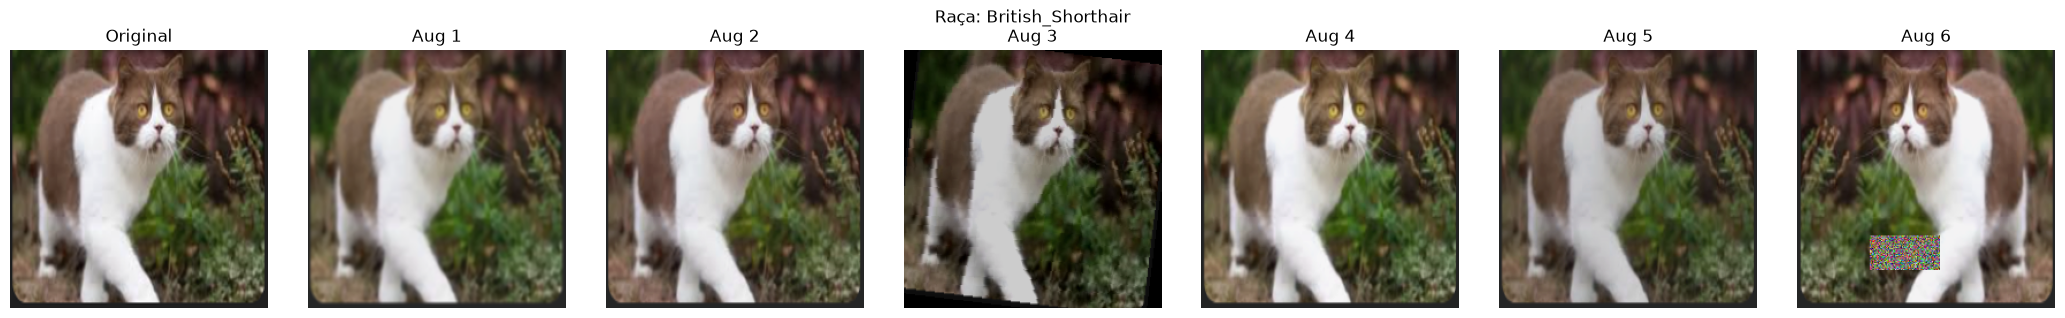

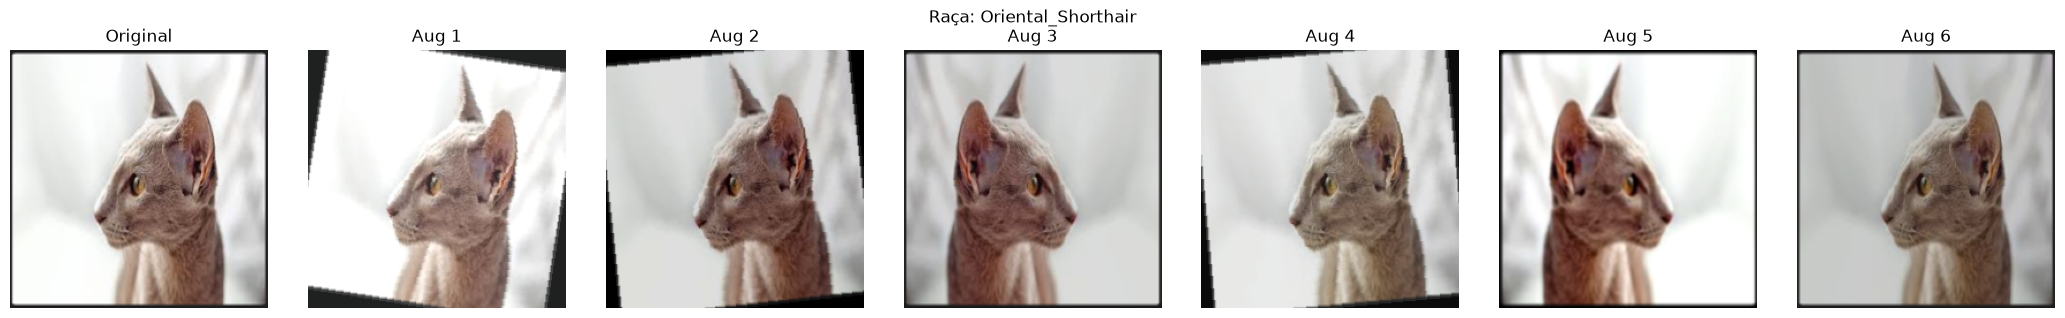

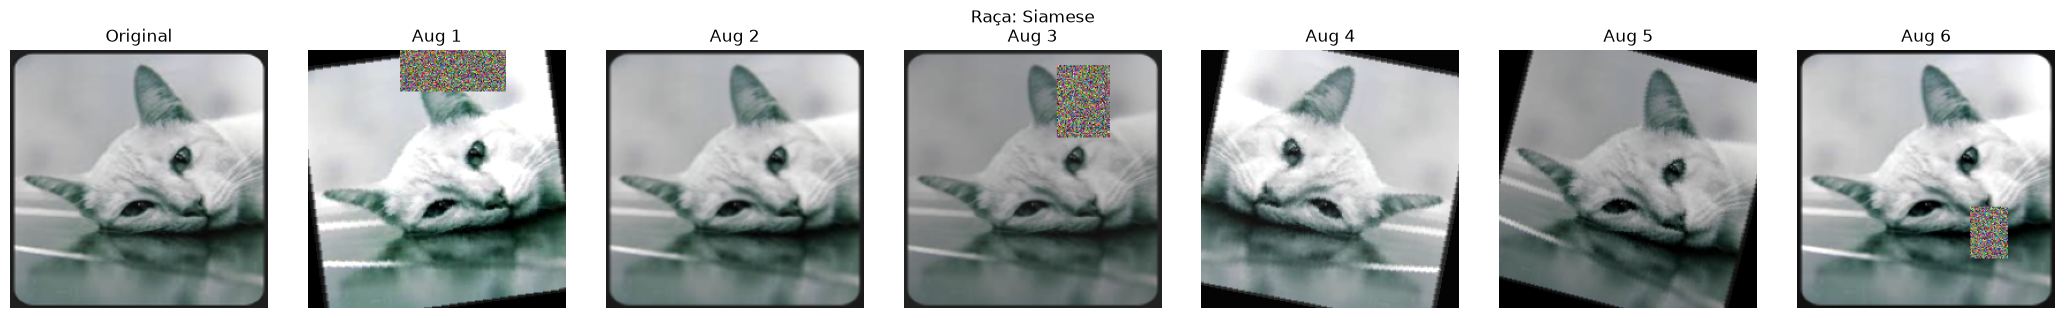

In [12]:
def denormalize(tensor_img):
    """Desfaz a normalização para poder plotar a imagem (valores em [0,1])."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = tensor_img.clone() * std + mean
    return img.clamp(0, 1)


def show_augmentations(dataframe, n_examples=3, n_augmentations=6):
    sample_rows = dataframe.sample(n=n_examples, random_state=CONFIG["SEED"])
    for _, row in sample_rows.iterrows():
        original = Image.open(row["filepath"]).convert("RGB")

        fig, axes = plt.subplots(1, n_augmentations + 1, figsize=(3 * (n_augmentations + 1), 3.2))
        axes[0].imshow(original.resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])))
        axes[0].set_title("Original")
        axes[0].axis("off")

        for i in range(n_augmentations):
            aug_tensor = train_tfms(original)
            aug_img = denormalize(aug_tensor).permute(1, 2, 0).numpy()
            axes[i + 1].imshow(aug_img)
            axes[i + 1].set_title(f"Aug {i + 1}")
            axes[i + 1].axis("off")

        fig.suptitle(f"Raça: {row['breed_name']}")
        plt.tight_layout()
        plt.show()


# Antes do split ainda não existe train_df; o demo só ilustra as transformações.
show_augmentations(cats_df, n_examples=3, n_augmentations=6)

<a id="7"></a>
## 7. Divisão treino / validação / teste
**Checklist 7**

Split **estratificado** 70/15/15 com `train_test_split`, semente 42. A
estratificação garante que todas as 22 raças aparecem nos três conjuntos, na
mesma proporção.

Três `assert` protegem contra **data leakage**: nenhuma imagem com o mesmo
SHA-256 pode estar em dois conjuntos. Se a limpeza falhasse, o notebook parava
aqui em vez de reportar uma métrica inflada.

In [13]:
breed_names = sorted(cats_df["breed_name"].unique())
breed_to_idx = {b: i for i, b in enumerate(breed_names)}
idx_to_breed = {i: b for b, i in breed_to_idx.items()}
NUM_CLASSES = len(breed_names)

cats_df["label"] = cats_df["breed_name"].map(breed_to_idx)

# Split estratificado com train_test_split (proporções exatas do CONFIG).
# Correção em relação à versão anterior: o split manual usava int() para
# calcular o tamanho de cada fatia, e a sobra do arredondamento sempre
# caía no conjunto de teste (assimetria). Com train_test_split + stratify
# a divisão fica proporcional e sem esse viés.
val_frac = CONFIG["VAL_FRAC"]
test_frac = CONFIG["TEST_FRAC"]

train_df, temp_df = train_test_split(
    cats_df,
    test_size=(val_frac + test_frac),
    stratify=cats_df["label"],
    random_state=CONFIG["SEED"],
)

# Dentro do "temp_df", divide entre val e teste mantendo a proporção pedida
relative_test_frac = test_frac / (val_frac + test_frac)
val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_frac,
    stratify=temp_df["label"],
    random_state=CONFIG["SEED"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Treino: {len(train_df)} | Validação: {len(val_df)} | Teste: {len(test_df)}")

# Registra os splits e verifica que uma imagem idêntica não aparece em dois conjuntos.
split_frames = {"train": train_df, "val": val_df, "test": test_df}
for split_name, split_df in split_frames.items():
    split_df.to_csv(ARTIFACTS_DIR / f"{split_name}_manifest.csv", index=False)
    assert set(split_df["breed_name"]) == set(breed_names), f"Classe ausente em {split_name}"
assert set(train_df["image_sha256"]).isdisjoint(val_df["image_sha256"])
assert set(train_df["image_sha256"]).isdisjoint(test_df["image_sha256"])
assert set(val_df["image_sha256"]).isdisjoint(test_df["image_sha256"])

Treino: 5036 | Validação: 1079 | Teste: 1080


In [14]:
# DataLoaders — com workers e pin_memory quando há GPU.
loaders = ce.montar_loaders({"train": train_df, "val": val_df, "test": test_df},
                            CONFIG, acel)
train_loader, val_loader, test_loader = loaders["train"], loaders["val"], loaders["test"]
print(f"Batches — treino: {len(train_loader)} · validação: {len(val_loader)} "
      f"· teste: {len(test_loader)}")
print(acel)

Batches — treino: 79 · validação: 17 · teste: 17
Acelerador(device=cuda, precisão=bfloat16 (AMP), workers=8)


<a id="8"></a>
## 8. Arquitetura e justificativa
**Checklist 8 · Rubrica: implementação e compreensão da arquitetura (20%)**

**ResNet50 pré-treinada na ImageNet, com transfer learning.**

- *Por que residual:* as conexões de atalho permitem profundidade sem degradar
  o gradiente, e profundidade é o que captura textura de pelagem.
- *Por que transfer learning:* 7.195 imagens é pouco para treinar 23,5 M de
  parâmetros do zero. As features iniciais da ImageNet (bordas, texturas) já
  servem; só o topo precisa aprender a tarefa.
- *Cabeça:* `Dropout(0,5)` + `Linear(2048 → 22)`. O dropout reduz o sobreajuste
  na fase em que só a cabeça treina.
- *Detector:* YOLOv8n com pesos COCO, **sem** treino próprio. A detecção aqui é
  pré-processamento; o trabalho pede classificação.
- *Custo:* modelo médio, poucas épocas e early stopping, como recomenda a
  Seção 12.1 do enunciado.

figura salva em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/pipeline.png


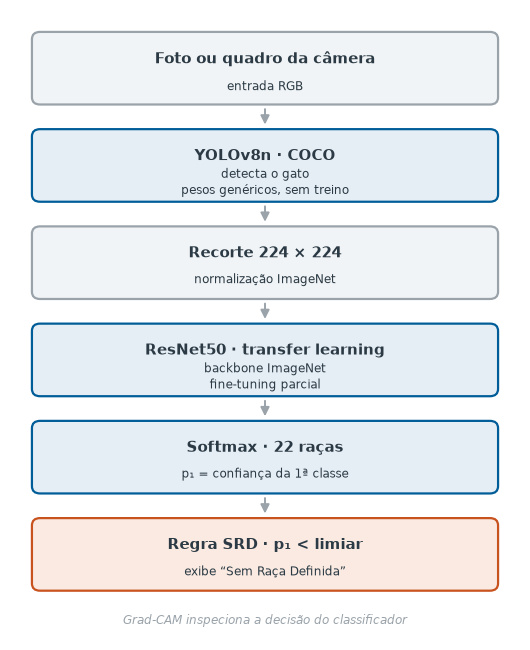

In [15]:
# Diagrama do pipeline — figura da apresentação.
cg.pipeline_diagrama()
plt.show()

In [16]:
# Contagem de parâmetros por configuração de descongelamento.
modelo_exemplo = ce.build_model(NUM_CLASSES, CONFIG["DROPOUT"], acel)
print(modelo_exemplo.fc)

total = sum(p.numel() for p in modelo_exemplo.parameters())
print(f"\nParâmetros totais da ResNet50 + cabeça: {total / 1e6:.2f} M")
for nome, camadas in (("só a cabeça (fc)", ["fc"]),
                      ("layer4 + fc", ["layer4", "fc"]),
                      ("layer3 + layer4 + fc", ["layer3", "layer4", "fc"])):
    n = sum(p.numel() for k, p in modelo_exemplo.named_parameters()
            if any(c in k for c in camadas))
    print(f"  treináveis com {nome:<24} {n / 1e6:6.2f} M  ({n / total:5.1%})")

del modelo_exemplo

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=22, bias=True)
)

Parâmetros totais da ResNet50 + cabeça: 23.55 M
  treináveis com só a cabeça (fc)           0.05 M  ( 0.2%)
  treináveis com layer4 + fc               15.01 M  (63.7%)
  treináveis com layer3 + layer4 + fc      22.11 M  (93.9%)


<a id="9"></a>
## 9. Metodologia de treinamento
**Checklist 9 · Rubrica: exploração experimental (20%)**

Treino em **duas fases**, o que define o baseline e a variação:

1. **Cabeça** — backbone congelado, só a `fc` treina, taxa 1e-3.
2. **Fine-tuning** — descongela os últimos blocos, taxa 1e-5 (100× menor, para
   refinar sem destruir o que veio da ImageNet).

Controles em ambas: `CrossEntropyLoss` com label smoothing 0,05, weight decay
3e-4, `ReduceLROnPlateau` e **early stopping** por `val_loss` com paciência 5 e
restauração automática dos melhores pesos.

O código roda a partir de `cat_experimentos.py` — o mesmo módulo usado pelos
scripts de linha de comando, para não existirem duas implementações que possam
divergir. As duas peças centrais estão impressas abaixo.

In [17]:
import inspect

print(inspect.getsource(ce.EarlyStopping))
print(inspect.getsource(ce.train_phase))

class EarlyStopping:
    """Igual ao do notebook: para quando val_loss estagna e restaura o melhor estado."""

    def __init__(self, patience: int = 5, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, val_loss: float, model: nn.Module) -> bool:
        improved = self.best_score is None or val_loss < (self.best_score - self.min_delta)
        if improved:
            self.best_score = val_loss
            self.counter = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return improved

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.b

<a id="10"></a>
## 10. Plano de experimentos
**Checklist 9 e 10 · Rubrica: exploração experimental (20%)**

O enunciado (Seção 9) exige **três configurações**: um baseline e ao menos duas
variações. Cada experimento muda **uma** variável; dados, split, semente,
otimizador, scheduler e critério de parada são idênticos.

| Exp. | Configuração | Variável alterada | Hipótese |
|---|---|---|---|
| **E1** | Baseline: backbone congelado, só a cabeça | — | Quanto a ImageNet já resolve sem ajustar convoluções |
| **E2** | E1 + fine-tuning de `layer3`, `layer4` e `fc` | Camadas descongeladas | Especializar os dois últimos blocos eleva acurácia e F1-macro |
| **E3** | E1 + fine-tuning de `layer4` e `fc` | Profundidade do descongelamento | Menos parâmetros treináveis reduzem o sobreajuste |
| **E4** | E2 sem data augmentation *(extra)* | Regularização | Sem augmentation o gap treino−validação cresce |

A fase da cabeça é idêntica em E1, E2 e E3, então é treinada **uma vez** e
reaproveitada — não altera o resultado e corta um terço do tempo.

> Em GPU, E1 + E2 + E3 levam cerca de 10 minutos. Acrescente `"E4"` à lista para
> o experimento extra.

In [18]:
EXPERIMENTOS_A_RODAR = ["E1", "E2", "E3"]

tabela_exp = ce.rodar_experimentos(
    EXPERIMENTOS_A_RODAR, {"train": train_df, "val": val_df, "test": test_df},
    breed_names, acel, EXP_DIR, config=CONFIG,
)


E1 — Baseline — somente a cabeça
Variável alterada: —
Hipótese: Estabelecer a referência: quanto a ResNet50 da ImageNet já resolve sem ajustar nenhuma camada convolucional.
[Head] Epoch 1/30 | Train loss: 2.4350 acc: 0.3894 | Val loss: 1.9464 acc: 0.5876 | 41s | melhor val_loss
[Head] Epoch 2/30 | Train loss: 1.7652 acc: 0.5856 | Val loss: 1.5968 acc: 0.6478 | 5s | melhor val_loss
[Head] Epoch 3/30 | Train loss: 1.5451 acc: 0.6362 | Val loss: 1.4335 acc: 0.6747 | 5s | melhor val_loss
[Head] Epoch 4/30 | Train loss: 1.4129 acc: 0.6734 | Val loss: 1.3611 acc: 0.6923 | 5s | melhor val_loss
[Head] Epoch 5/30 | Train loss: 1.3329 acc: 0.6924 | Val loss: 1.3086 acc: 0.6997 | 5s | melhor val_loss
[Head] Epoch 6/30 | Train loss: 1.2927 acc: 0.6948 | Val loss: 1.2782 acc: 0.7071 | 5s | melhor val_loss
[Head] Epoch 7/30 | Train loss: 1.2425 acc: 0.7151 | Val loss: 1.2568 acc: 0.7108 | 5s | melhor val_loss
[Head] Epoch 8/30 | Train loss: 1.2206 acc: 0.7242 | Val loss: 1.2374 acc: 0.7266 | 5s | m

<a id="11"></a>
## 11. Histórico de treinamento
**Checklist 11**

As curvas de loss e acurácia por época, com o início do fine-tuning marcado.
A distância entre treino e validação é a leitura direta do sobreajuste.

Melhor experimento por F1-macro: E2
figura salva em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/historico_e1.png


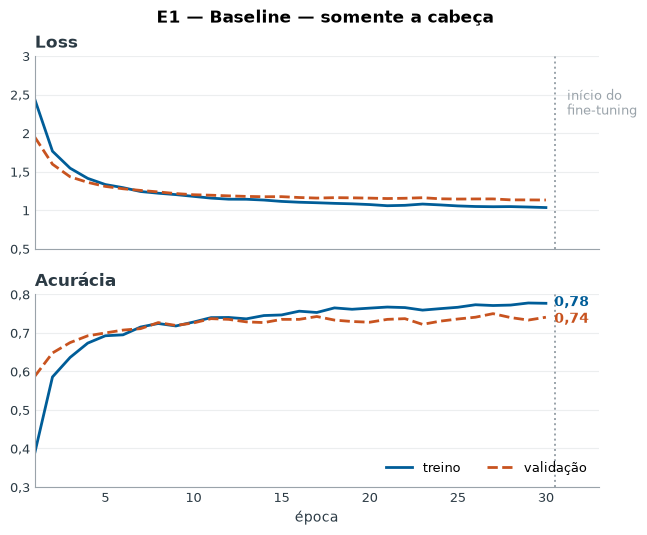

E1: treino 0.7766 · validação 0.7405 · gap 0.0361

figura salva em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/historico_e2.png


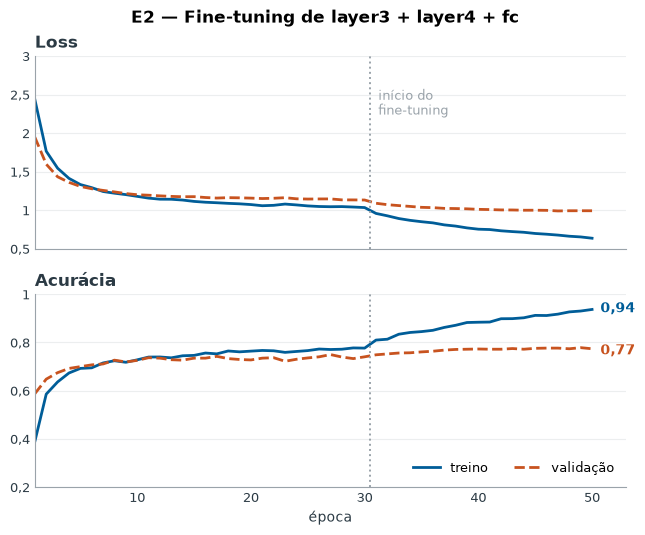

E2: treino 0.9371 · validação 0.7739 · gap 0.1632

figura salva em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/historico_e3.png


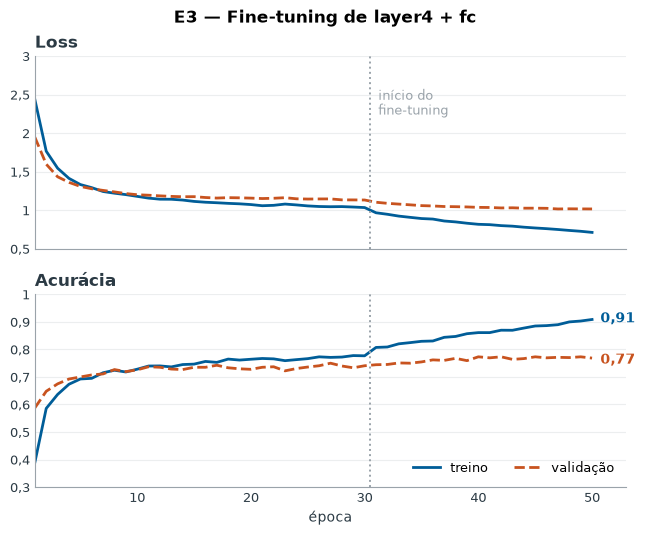

E3: treino 0.9085 · validação 0.7683 · gap 0.1402



In [19]:
MELHOR = tabela_exp.loc[tabela_exp["F1-macro (teste)"].idxmax(), "Exp."]
print(f"Melhor experimento por F1-macro: {MELHOR}")

for exp in EXPERIMENTOS_A_RODAR:
    hist = json.loads((EXP_DIR / exp / "historico.json").read_text(encoding="utf-8"))
    H = hist["historico"]
    cg.historico(H, hist["inicio_fine_tuning"], nome=f"historico_{exp.lower()}.png")
    plt.suptitle(f"{exp} — {ce.EXPERIMENTOS[exp]['nome']}", fontsize=12,
                 fontweight="bold", y=1.02)
    plt.show()
    print(f"{exp}: treino {H['train_acc'][-1]:.4f} · validação {H['val_acc'][-1]:.4f} "
          f"· gap {H['train_acc'][-1] - H['val_acc'][-1]:.4f}\n")

Ler o gap: em **E1** treino e validação andam juntas — o modelo não tem
capacidade para decorar, porque só 0,05 M de parâmetros treinam. Em **E2** as
curvas se separam depois do fine-tuning: os 22 M de parâmetros liberados
aprendem o conjunto de treino mais rápido do que generalizam. O early stopping
e a restauração dos melhores pesos contêm o efeito, mas não o eliminam — e é
essa troca que a Seção 13 quantifica.

<a id="12"></a>
## 12. Métricas e avaliação
**Checklist 12 · Rubrica: avaliação e análise dos resultados (20%)**

A métrica principal é o **F1-macro**, não a acurácia. Com classes de 27 a 85
imagens no teste, a acurácia é dominada pelas raças grandes e esconde o
desempenho das pequenas — exatamente o que o enunciado alerta na Seção 8.1.

Reportamos acurácia, F1-macro, precisão e recall por classe, e a matriz de
confusão normalizada por linha (sem normalizar, as classes grandes dominariam
a escala de cor).

In [20]:
# Carrega o melhor modelo e avalia no conjunto de teste.
model, breed_names_ckpt, cfg_ckpt = ce.carregar_checkpoint(
    EXP_DIR / MELHOR / "classificador.pt", acel)
idx_to_breed = {i: b for i, b in enumerate(breed_names_ckpt)}

metricas = json.loads((EXP_DIR / MELHOR / "metricas.json").read_text(encoding="utf-8"))
print(f"Acurácia no teste: {metricas['acuracia']:.4f}")
print(f"F1-score (macro):  {metricas['f1_macro']:.4f}\n")
print(metricas["relatorio_texto"])

Checkpoint: /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/experimentos/E2/classificador.pt (22 classes, experimento E2)
Acurácia no teste: 0.8093
F1-score (macro):  0.7844

                    precision    recall  f1-score   support

        Abyssinian       0.84      0.91      0.87        65
American_Shorthair       0.75      0.72      0.74        29
            Bengal       0.88      0.89      0.89        65
            Birman       0.73      0.68      0.70        63
            Bombay       0.90      0.96      0.93        27
 British_Shorthair       0.89      0.89      0.89        61
       Cornish_Rex       0.59      0.57      0.58        35
         Devon_Rex       0.57      0.55      0.56        31
      Egyptian_Mau       0.93      0.93      0.93        28
         Himalayan       0.68      0.58      0.62        33
        Maine_Coon       0.81      0.85      0.83        85
              Manx       0.61      0.66      0.63        35
  Norwegian_Forest   

figura salva em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/f1_por_classe.png


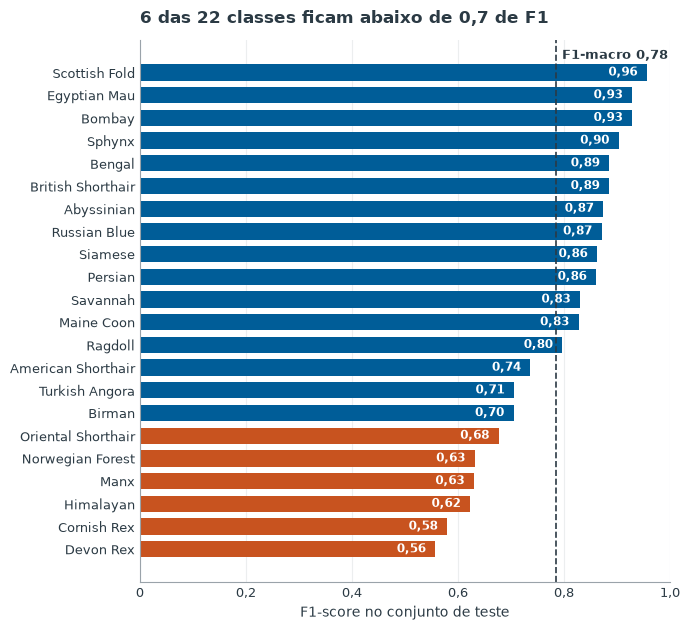

In [21]:
# F1 por classe — figura da apresentação.
cg.f1_por_classe(metricas)
plt.show()

figura salva em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/matriz_confusao.png


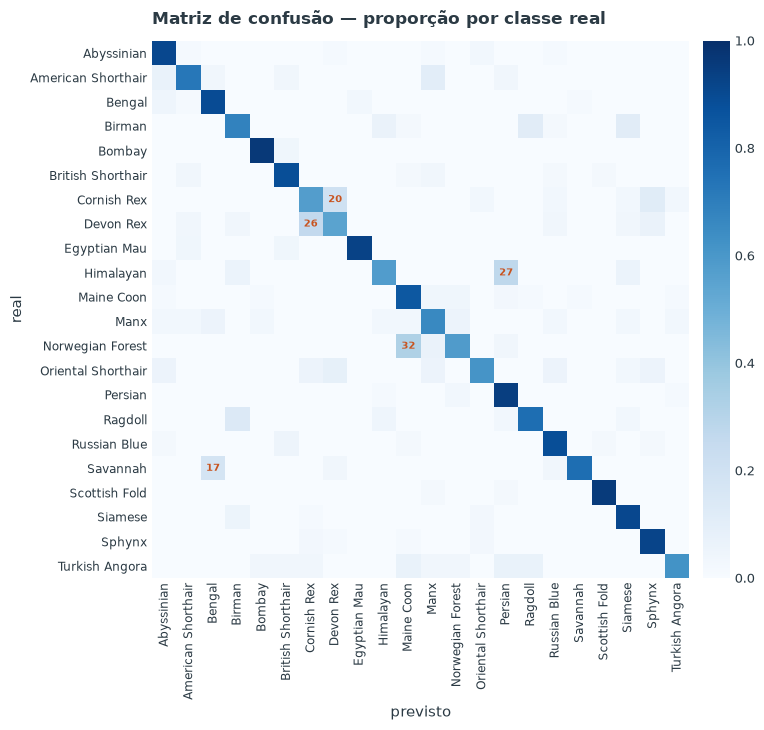

Confusões mais frequentes (real → previsto):
  Norwegian_Forest     → Maine_Coon            10
  Himalayan            → Persian                9
  Ragdoll              → Birman                 9
  Devon_Rex            → Cornish_Rex            8
  Birman               → Ragdoll                7
  Birman               → Siamese                7
  Cornish_Rex          → Devon_Rex              7
  Savannah             → Bengal                 5


In [22]:
# Matriz de confusão — figura da apresentação.
logits_test, y_test = ce.coletar_logits(model, test_loader, acel)
preds_test = logits_test.argmax(axis=1)
cg.matriz_confusao(y_test, preds_test, breed_names)
plt.show()

# As confusões mais frequentes, em pares.
cm = confusion_matrix(y_test, preds_test)
pares = [(breed_names[i], breed_names[j], cm[i, j])
         for i in range(len(breed_names)) for j in range(len(breed_names))
         if i != j and cm[i, j] > 0]
pares.sort(key=lambda p: -p[2])
print("Confusões mais frequentes (real → previsto):")
for real, previsto, n in pares[:8]:
    print(f"  {real:<20} → {previsto:<20} {n:3d}")

<a id="13"></a>
## 13. Resultados comparados
**Checklist 13 · Tabela 4 do enunciado**

A tabela e o gráfico abaixo são a resposta direta a duas perguntas da Seção
14.1: *qual alteração experimental produziu maior impacto* e *houve
sobreajuste, e como foi identificado*.

,Exp.,Configuração,Variável alterada,Parâmetros treináveis (M),Épocas,Acurácia (teste),F1-macro (teste),Gap treino−val,Tempo (min)
0,E1,Baseline — somente a cabeça,—,0.05,30,0.7556,0.7254,0.0361,3.5
1,E2,Fine-tuning de layer3 + layer4 + fc,Camadas descongeladas (arquitetura),22.11,50,0.8093,0.7844,0.1632,2.8
2,E3,Fine-tuning de layer4 + fc,Profundidade do descongelamento (arquitetura),15.01,50,0.7972,0.7733,0.1402,2.6


figura salva em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/comparativo_experimentos.png


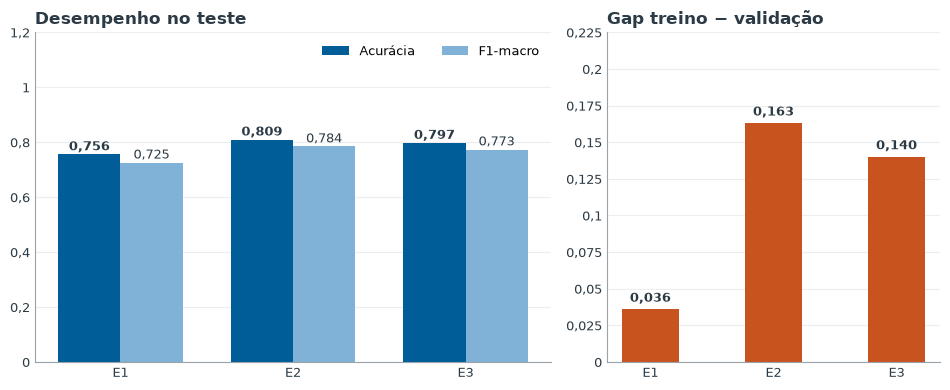

E2 sobre o baseline: +5.4 pontos de acurácia, +5.9 de F1-macro
Custo: o gap treino−validação vai de 0.036 para 0.163


In [23]:
COLUNAS = ["Exp.", "Configuração", "Variável alterada", "Parâmetros treináveis (M)",
           "Épocas", "Acurácia (teste)", "F1-macro (teste)", "Gap treino−val", "Tempo (min)"]
display(tabela_exp[[c for c in COLUNAS if c in tabela_exp.columns]])

cg.comparativo_experimentos(tabela_exp)
plt.show()

base = tabela_exp[tabela_exp["Exp."] == "E1"].iloc[0]
melhor = tabela_exp.loc[tabela_exp["F1-macro (teste)"].idxmax()]
print(f"{melhor['Exp.']} sobre o baseline: "
      f"{(melhor['Acurácia (teste)'] - base['Acurácia (teste)']) * 100:+.1f} pontos de acurácia, "
      f"{(melhor['F1-macro (teste)'] - base['F1-macro (teste)']) * 100:+.1f} de F1-macro")
print(f"Custo: o gap treino−validação vai de {base['Gap treino−val']:.3f} "
      f"para {melhor['Gap treino−val']:.3f}")

<a id="14"></a>
## 14. Modelo final para a aplicação

O melhor experimento vira `artifacts/cat_breed_classifier.pt`, que é o arquivo
lido pela webcam local (`webcam.py`) e pela exportação ONNX
(`export_web_models.sh`) que alimenta o app web.

In [24]:
MODEL_PATH = ARTIFACTS_DIR / "cat_breed_classifier.pt"
shutil.copy2(EXP_DIR / MELHOR / "classificador.pt", MODEL_PATH)
print(f"Modelo de {MELHOR} salvo em {MODEL_PATH}")
print(f"Classes: {len(breed_names)} · tamanho: {MODEL_PATH.stat().st_size / 1e6:.1f} MB")

Modelo de E2 salvo em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/cat_breed_classifier.pt
Classes: 22 · tamanho: 94.5 MB


<a id="15"></a>
## 15. Interpretabilidade: detecção, Grad-CAM e pipeline completo

O Grad-CAM mostra quais regiões pesaram na decisão do classificador. Ele
**não** demonstra causalidade nem comprova a raça — serve para checar se o
modelo está olhando para o gato e não para o fundo.

In [25]:
# ultralytics já foi instalado pelo requirements.txt na seção de setup.

In [26]:
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")  # versão "nano": rápida e leve, ótima para este pipeline

# Índice da classe "cat" no COCO (dataset em que o YOLO foi treinado)
COCO_CAT_CLASS_ID = 15


def detect_cat_bbox(image_path, conf_threshold=0.25):
    """Retorna a bounding box (x1, y1, x2, y2) do gato com maior confiança,
    ou None se nenhum gato for detectado."""
    results = yolo_model(image_path, verbose=False)[0]

    best_box = None
    best_conf = 0.0

    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        if cls_id == COCO_CAT_CLASS_ID and conf > conf_threshold and conf > best_conf:
            best_conf = conf
            best_box = box.xyxy[0].cpu().numpy()  # [x1, y1, x2, y2]

    return best_box, best_conf

In [27]:
# grad-cam já foi instalado pelo requirements.txt na seção de setup.

In [28]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Última camada convolucional da ResNet50 (boa escolha padrão para Grad-CAM)
target_layers = [model.layer4[-1]]
gradcam = GradCAM(model=model, target_layers=target_layers)


def generate_gradcam(pil_crop_img):
    """Recebe um crop PIL do gato (RGB) e retorna:
    - a imagem com heatmap sobreposto (numpy uint8)
    - a classe prevista (nome da raça)
    - a confiança da predição
    """
    img_resized = pil_crop_img.resize((IMG_SIZE, IMG_SIZE))
    rgb_img = np.array(img_resized).astype(np.float32) / 255.0

    input_tensor = eval_tfms(pil_crop_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = int(probs.argmax())
        pred_conf = float(probs[pred_idx])

    grayscale_cam = gradcam(input_tensor=input_tensor,
                             targets=[ClassifierOutputTarget(pred_idx)])[0]
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    return cam_image, idx_to_breed[pred_idx], pred_conf

### 15.1. Pontos faciais — etapa opcional

O YOLO Pose estima nove pontos (olhos, boca e orelhas) a partir do
[CAT Dataset](https://www.kaggle.com/datasets/crawford/cat-dataset/data). É uma
etapa **opcional**: os pontos são exibidos, mas **não** entram como features do
classificador — a ResNet50 continua recebendo apenas o recorte RGB. Está
desativada por padrão (`LANDMARKS_MODE="off"`); mude para `"train"` na Seção 2.1
para gerar os resultados.

In [29]:
from cat_landmarks import (
    download_landmarks, prepare_landmarks, train_landmarks,
    load_landmark_model, detect_landmarks, draw_landmarks,
)

landmark_model = None
landmark_mode = CONFIG["LANDMARKS_MODE"]
if landmark_mode not in ("off", "train", "load"):
    raise ValueError('LANDMARKS_MODE deve ser "off", "train" ou "load".')
landmark_root = Path.cwd().resolve()
landmark_path = landmark_root / "artifacts" / "cat_landmarks.pt"
if landmark_mode == "train":
    raw_landmarks = download_landmarks(landmark_root / "data")
    landmarks_yaml = prepare_landmarks(
        raw_landmarks, landmark_root / "data" / "cat_landmarks_pose", seed=CONFIG["SEED"],
    )
    train_landmarks(
        landmarks_yaml, landmark_path, epochs=CONFIG["LANDMARKS_EPOCHS"],
        batch=CONFIG["LANDMARKS_BATCH"], image_size=CONFIG["LANDMARKS_IMG_SIZE"],
        device=str(device), seed=CONFIG["SEED"],
    )
if landmark_mode != "off":
    landmark_model = load_landmark_model(landmark_path)
    print("Pontos faciais ativos:", landmark_path)
else:
    print('Pontos faciais desativados. Use LANDMARKS_MODE="train" na primeira execução.')

Pontos faciais desativados. Use LANDMARKS_MODE="train" na primeira execução.


In [30]:
if CONFIG.get("LANDMARKS_MODE", "off") != "off" and CONFIG.get("LANDMARKS_SHOW_RESULTS", True):
    from cat_landmarks import show_landmark_results
    if globals().get("landmark_model") is None:
        print("Execute a célula de treino/carga dos pontos faciais antes dos resultados.")
    else:
        show_landmark_results(
            landmark_path, landmark_model, landmark_root / "data" / "cat_landmarks_pose",
            device=str(device), examples=CONFIG.get("LANDMARKS_EXAMPLES", 3),
            conf=CONFIG["LANDMARKS_CONF"], seed=CONFIG["SEED"],
        )

### 15.2. Pipeline completo

Junta tudo: detecção → recorte → pontos faciais (se ativos) → classificação →
Grad-CAM.

In [31]:
import cv2
from IPython.display import display
from cat_landmarks import landmark_table


def full_pipeline(image_path, show=True, true_breed=None):
    """Roda o pipeline completo: detecção (YOLO) -> crop -> pontos faciais -> classificação.

    Se um gato for detectado, também gera o Grad-CAM. Se NENHUM gato for
    detectado, pula a etapa de Grad-CAM (não faz sentido gerar o heatmap
    de uma imagem que pode nem conter o objeto de interesse) e classifica
    a imagem inteira como fallback, sem mostrar o heatmap.

    Se `true_breed` for informado (raça real conhecida), ela é mostrada ao
    lado da predição para facilitar ver se o modelo acertou ou errou.
    """
    original = Image.open(image_path).convert("RGB")

    bbox, det_conf = detect_cat_bbox(image_path)
    cat_found = bbox is not None

    if not cat_found:
        print(f"Aviso: nenhum gato detectado em {image_path}")
        crop = original  # fallback: usa a imagem inteira
        bbox_used = None
    else:
        x1, y1, x2, y2 = map(int, bbox)
        crop = original.crop((x1, y1, x2, y2))
        bbox_used = (x1, y1, x2, y2)

    facial_features = None
    features_enabled = CONFIG.get("LANDMARKS_MODE", "off") != "off" and globals().get("landmark_model") is not None
    if cat_found and features_enabled:
        facial_features = detect_landmarks(crop, landmark_model, device,
                                           conf=CONFIG["LANDMARKS_CONF"])

    if cat_found:
        # Só gera o Grad-CAM quando um gato foi de fato encontrado
        cam_image, breed, breed_conf = generate_gradcam(crop)
    else:
        # Classifica sem gerar o heatmap
        cam_image = None
        img_tensor = eval_tfms(crop).unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = model(img_tensor)
            probs = torch.softmax(outputs, dim=1)[0]
            pred_idx = int(probs.argmax())
            breed_conf = float(probs[pred_idx])
        breed = idx_to_breed[pred_idx]

    is_correct = None
    if true_breed is not None:
        is_correct = (breed == true_breed)
        resultado = "CORRETO" if is_correct else "ERRADO"
        print(f"Predito: {breed} ({breed_conf:.1%})  |  Real: {true_breed}  |  {resultado}")

    if show:
        n_panels = (4 if features_enabled else 3) if cat_found else 2
        fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
        if n_panels == 2:
            axes = list(axes)

        # 1. Imagem original com bbox (se houver)
        img_with_box = np.array(original).copy()
        if bbox_used:
            x1, y1, x2, y2 = bbox_used
            cv2.rectangle(img_with_box, (x1, y1), (x2, y2), (0, 255, 0), 3)
            cv2.putText(img_with_box, f"cat {det_conf:.2f}", (x1, max(y1 - 10, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        axes[0].imshow(img_with_box)
        axes[0].set_title("Deteccao (YOLOv8)" if cat_found else "Nenhum gato detectado")
        axes[0].axis("off")

        pred_title = f"Predito: {breed} ({breed_conf:.1%})"
        if true_breed is not None:
            pred_title += f"\nReal: {true_breed} ({'correto' if is_correct else 'errado'})"

        if cat_found:
            # 2. Crop usado na classificação
            axes[1].imshow(crop)
            axes[1].set_title("Crop do gato")
            axes[1].axis("off")

            cam_axis = 2
            if features_enabled:
                axes[2].imshow(draw_landmarks(np.array(crop), facial_features))
                point_count = sum(p["visible"] for p in facial_features["points"].values()) if facial_features else 0
                axes[2].set_title(f"Features faciais — {point_count}/9 pontos")
                axes[2].axis("off")
                cam_axis = 3

            axes[cam_axis].imshow(cam_image)
            axes[cam_axis].set_title(f"Grad-CAM\n{pred_title}")
            axes[cam_axis].axis("off")
        else:
            # Sem detecção: mostra só a classificação de fallback, sem Grad-CAM
            axes[1].imshow(crop)
            axes[1].set_title(pred_title)
            axes[1].axis("off")

        plt.tight_layout()
        plt.show()
        if cat_found and features_enabled:
            display(landmark_table(facial_features).round(3))

    return {
        "bbox": bbox_used,
        "cat_found": cat_found,
        "detection_conf": det_conf,
        "facial_features": facial_features,  # coordenadas relativas ao crop
        "breed": breed,
        "breed_conf": breed_conf,
        "true_breed": true_breed,
        "correct": is_correct,
    }

Aviso: nenhum gato detectado em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/data/Cat-Breeds-Dataset-56a69059119626ed210023bbfc6fdcb8262e8703/images/sphynx_cat/005.png
Predito: Sphynx (45.3%)  |  Real: Sphynx  |  CORRETO


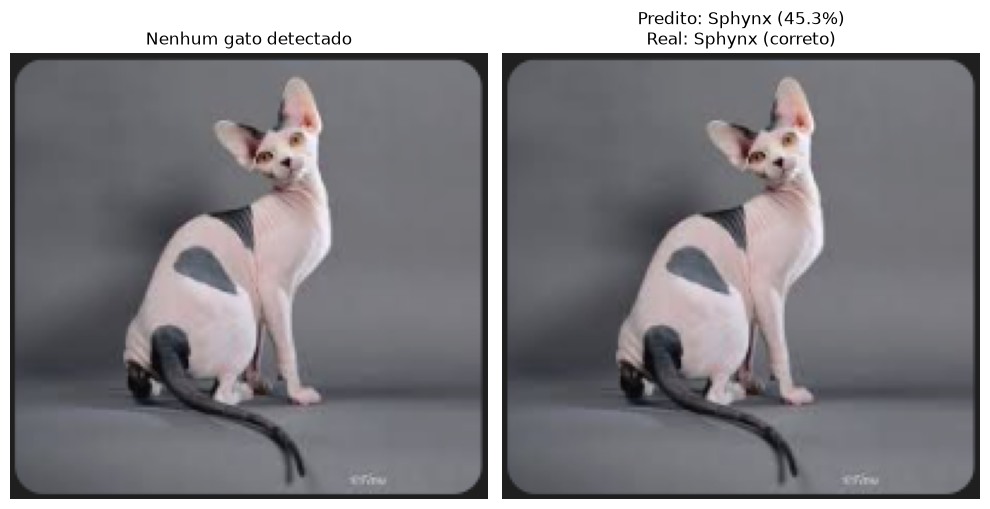

{'bbox': None, 'cat_found': False, 'detection_conf': 0.0, 'facial_features': None, 'breed': 'Sphynx', 'breed_conf': 0.45259737968444824, 'true_breed': 'Sphynx', 'correct': True}


In [32]:
# Teste rápido com uma imagem do próprio dataset
# (aqui já sabemos a raça real, então ela é passada para comparar com a predição)
sample_row = test_df.iloc[180]
sample_path = sample_row["filepath"]
sample_true_breed = sample_row["breed_name"]

result = full_pipeline(sample_path, true_breed=sample_true_breed)
print(result)

<a id="16"></a>
## 16. Generalização e a regra SRD
**Checklist 14 · Perguntas 5, 6 e 7 da Seção 14.1**

As fotos de `real_photos/` são gatos nossos, **sem raça definida**, tiradas com
celular. Elas não têm rótulo válido entre as 22 classes: o acerto aqui não é
classificar, é **rejeitar**.

É por isso que a avaliação por raça dessas fotos não faz sentido — e é também o
que expõe o limite do modelo. O softmax distribui 100% entre 22 raças, então
todo gato recebe alguma. A regra em produção rejeita abaixo de 40% de
confiança, um valor escolhido a olho. Esta seção mede se ele se sustenta.

30 fotos em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/real_photos


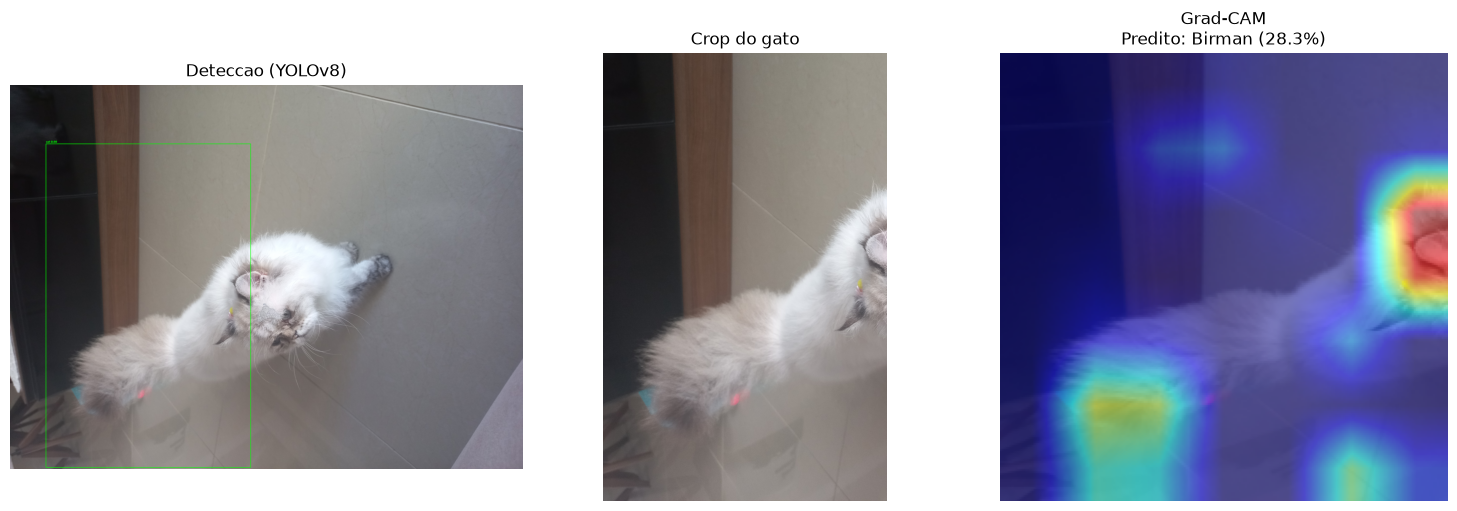

Aviso: nenhum gato detectado em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/real_photos/20230920_192542.jpg


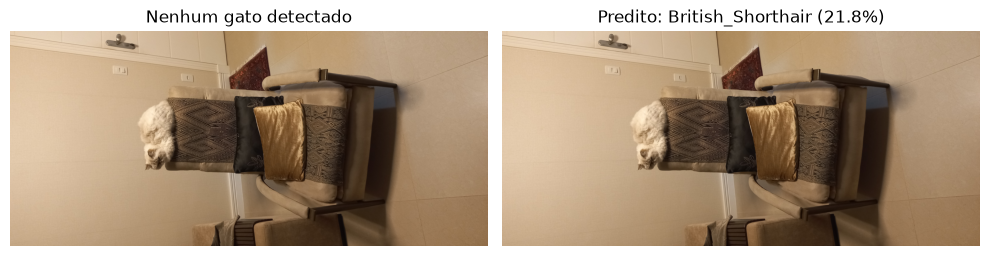

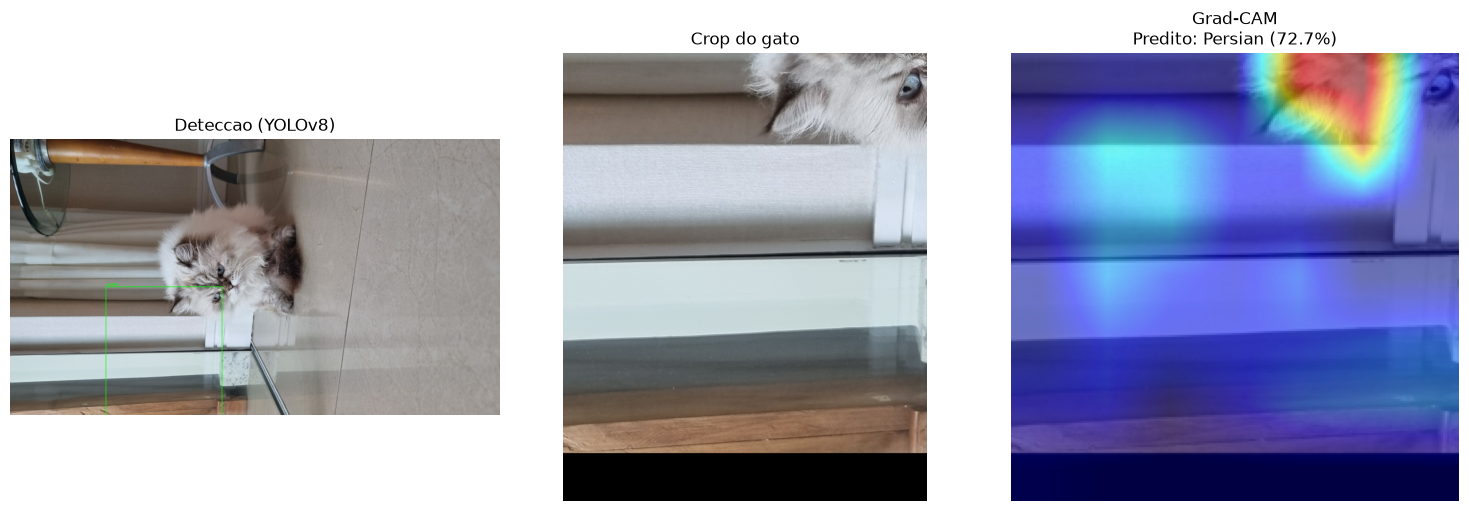

In [33]:
# Uma passada visual pelo pipeline em algumas fotos reais.
REAL_DATASET_DIR = PROJECT_DIR / "real_photos"
REAL_DATASET_DIR.mkdir(parents=True, exist_ok=True)
fotos_srd = sorted(p for p in REAL_DATASET_DIR.rglob("*")
                   if p.is_file() and p.suffix.lower() in ce.IMG_EXTENSIONS)
print(f"{len(fotos_srd)} fotos em {REAL_DATASET_DIR}")

for caminho in fotos_srd[:3]:
    full_pipeline(str(caminho))

### 16.1. Calibração, limiar e cobertura × acurácia

Três medidas:

1. **Calibração por temperatura** na validação — um único escalar *T* ajustado
   por NLL. Se *T* > 1, o modelo era superconfiante. O **ECE** antes e depois
   quantifica o quanto a confiança correspondia à taxa de acerto real.
2. **Varredura de limiar** no teste, por confiança máxima (p₁) e por margem
   entre a primeira e a segunda classe (p₁ − p₂): cobertura e acurácia entre os
   aceitos, em cada limiar.
3. **Conjunto de controle SRD** — as fotos de `real_photos/`, onde a métrica é
   a taxa de rejeição.

In [34]:
analise_srd = ce.analisar_srd(
    model, breed_names, {**cfg_ckpt, "BATCH_SIZE": CONFIG["BATCH_SIZE"]},
    {"train": train_df, "val": val_df, "test": test_df}, acel,
    out_dir=EXP_DIR / "srd",
    projeto=PROJECT_DIR,
    srd_dir=REAL_DATASET_DIR,
    alvo_acuracia=0.90,      # acurácia desejada entre as fotos aceitas
    limiar_atual=0.40,       # o limiar em uso hoje na webcam e no app
)


Calibração por temperatura: T = 0.871
ECE antes: 0.0381  |  depois: 0.0212
T = 0.87 < 1: o modelo estava subconfiante na validação.

Limiar atual (0.40): cobertura 95.0%, acurácia entre aceitos 83.7%
Para 90% de acurácia entre aceitos: limiar 0.65, cobertura 74.7%
YOLOv8: 25 recortes; 5 imagens sem gato detectado.

Conjunto de controle SRD: 30 fotos
No limiar 0.40, 23.3% são corretamente marcadas como SRD — as demais recebem uma raça que o gato não tem.
Raças mais atribuídas às fotos SRD: Persian (21), Maine_Coon (5), Ragdoll (3)

Resumo salvo em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/experimentos/srd/resumo.json


figura salva em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/srd_calibracao.png


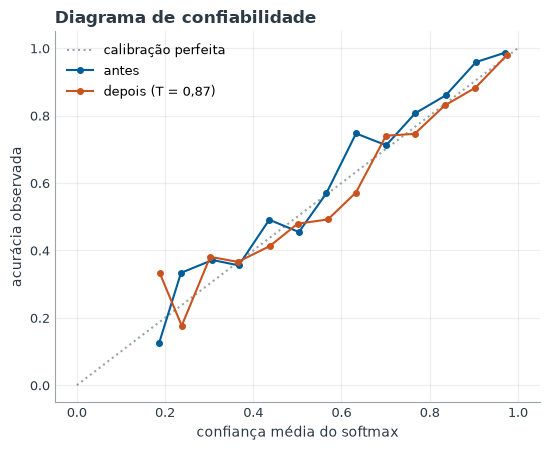

figura salva em /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/srd_limiar.png


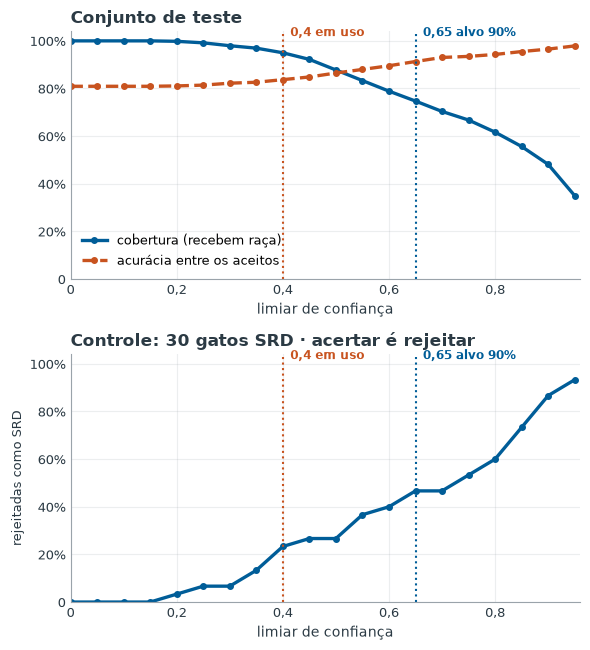

,criterio,limiar,cobertura,acuracia_aceitos,n_aceitos,erros_aceitos
6,confianca,0.30,0.9796,0.8223,1058,188
7,confianca,0.35,0.9694,0.8262,1047,182
8,confianca,0.40,0.9500,0.8372,1026,167
9,confianca,0.45,0.9222,0.8484,996,151
10,confianca,0.50,0.8778,0.8650,948,128
11,confianca,0.55,0.8333,0.8800,900,108
12,confianca,0.60,0.7889,0.8955,852,89
13,confianca,0.65,0.7472,0.9133,807,70
14,confianca,0.70,0.7037,0.9303,760,53
15,confianca,0.75,0.6676,0.9348,721,47


In [35]:
# Figuras da apresentação.
cg.srd_calibracao(analise_srd)
plt.show()
cg.srd_limiar(analise_srd, limiar_atual=0.40)
plt.show()

varredura = analise_srd["varreduras"]
display(varredura[(varredura["criterio"] == "confianca")
                  & (varredura["limiar"].between(0.30, 0.75))])

<a id="17"></a>
## 17. Limitações, conclusões e entregáveis
**Checklist 14 e 16 · Rubrica: relatório e apresentação (10%)**

### Limitações

- O classificador só conhece as **22 raças do conjunto de treino**. Qualquer
  outra — inclusive "nenhuma" — não tem rótulo correto disponível.
- **Confiança alta não é prova.** A Seção 16 mostra fotos SRD recebendo raça com
  confiança bem acima do limiar.
- O **detector** usa pesos COCO genéricos, sem ajuste para gatos.
- A limpeza remove duplicatas **RGB exatas**, não imagens semelhantes,
  recortadas ou recomprimidas.
- Iluminação, pose, enquadramento e fundo degradam o resultado em fotos
  externas, fora da distribuição dos datasets.
- O Grad-CAM indica regiões influentes, **não** causalidade.

### Conclusões

- O transfer learning entrega desempenho sólido com 7.195 imagens e custo
  compatível com a disciplina.
- O fine-tuning parcial vale os pontos que ganha, **mas o sobreajuste cresce
  junto**: é uma troca medida na Seção 13, não um ganho de graça.
- O erro **não é uniforme** — concentra-se em raças de pelo curto e rosto fino,
  visualmente próximas entre si (Seção 12).
- A métrica de raça **não representa o objetivo real**: um gato SRD não tem
  resposta certa entre as 22 classes, e a rejeição por confiança sozinha não
  resolve isso (Seção 16).

### O que melhoraria o sistema

Uma **classe SRD treinada**, com fotos de gatos comuns, em vez de uma regra de
limiar sobre o softmax. Mais dados nas raças fracas e um detector ajustado a
gatos também ajudariam.

### Entregáveis

| Item | Onde |
|---|---|
| Código e notebook | este repositório |
| Modelos exportados | `artifacts/`, e ONNX via `export_web_models.sh` |
| Aplicação web | [thiago-haas.github.io/mobile-onnx](https://thiago-haas.github.io/mobile-onnx/) |
| Figuras da apresentação | `artifacts/figuras/` |
| Resultados dos experimentos | `artifacts/experimentos/` |
| Checklist comentado | [`docs/CHECKLIST.md`](docs/CHECKLIST.md) |

> A webcam local não é executada neste notebook: ela depende de câmera e sessão
> gráfica. O código está em `webcam.py` (`./run_webcam.sh`), e a versão que roda
> no navegador está no repositório `mobile-onnx`.

In [36]:
print("Figuras geradas para a apresentação:\n")
for figura in cg.todas_as_figuras():
    print(f"  {figura}")
print(f"\nResultados dos experimentos em {EXP_DIR}")

Figuras geradas para a apresentação:

  /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/comparativo_experimentos.png
  /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/dist_classes.png
  /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/f1_por_classe.png
  /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/historico_e1.png
  /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/historico_e2.png
  /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/historico_e3.png
  /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/matriz_confusao.png
  /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/pipeline.png
  /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/artifacts/figuras/srd_calibracao.png
  /home/haas/Documents/GitHub/cnn-gatos-deteccao-classificacao/art